# Path-matching algorithm ranking

This notebook runs the controlled pairwise benchmark for the dense, sparse, and
beam path matchers.

The primary outputs are kept separate:

- **accuracy:** returned matching score as a percentage of the agreed exact
  optimum;
- **timing:** warm search time and setup-plus-warm-search time;
- **coverage:** whether the algorithm completed every intended instance.

Approximate methods are allowed to return suboptimal answers.  The notebook also
shows a harmonic timing/accuracy score, but treats it as a secondary convenience
rather than the main conclusion.  Planted-node recovery is not used as a
substitute for matching-score accuracy.

The default `smoke` run checks the pipeline quickly.  Use `standard` before
making performance comparisons.

## Imports and repository setup

Run the notebook from anywhere inside the repository checkout.  The bootstrap
below locates `pyproject.toml` and places `src/` on `sys.path`; an editable
installation is still recommended.

In [1]:
from __future__ import annotations

from collections.abc import Mapping
from copy import deepcopy
from pathlib import Path
from time import perf_counter
import json
import re
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def find_repository_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "src").is_dir():
            return candidate
    raise RuntimeError(
        "Could not find the repository root. Run this notebook from inside the "
        "tree_matching checkout."
    )


def normalize_selection(value, *, available: list[str], setting_name: str) -> list[str]:
    if value == "all":
        selected = list(available)
    elif isinstance(value, str):
        selected = [value]
    else:
        selected = [str(item) for item in value]

    if not selected:
        raise ValueError(f"{setting_name} must select at least one item")
    if len(set(selected)) != len(selected):
        raise ValueError(f"{setting_name} contains duplicate entries: {selected}")

    unknown = sorted(set(selected).difference(available))
    if unknown:
        raise ValueError(
            f"Unknown {setting_name.lower()}: {unknown}. Available values are {available}."
        )

    # Retain preset order so filtering does not create a new execution-order convention.
    selected_set = set(selected)
    return [name for name in available if name in selected_set]


def normalize_run_label(value: str | None) -> str | None:
    if value is None or not str(value).strip():
        return None
    label = str(value).strip()
    if re.fullmatch(r"[A-Za-z0-9][A-Za-z0-9._-]*", label) is None:
        raise ValueError(
            "RUN_LABEL must start with a letter or digit and contain only letters, "
            "digits, '.', '_', or '-'."
        )
    return label


ROOT = find_repository_root()
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from benchmarking import (  # noqa: E402
    load_config,
    resolve_algorithm_specs,
    run_benchmark_config,
)

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 200)
print(f"Repository root: {ROOT}")


Repository root: /home/asmi28/python_code/tree_matching


## User settings

The controls below are deliberately compact. `SCALE` chooses a versioned preset;
`REGIMES` and `ALGORITHMS` select subsets without changing their preset order;
`SIZE_OVERRIDES` changes only tree size/depth fields for named regimes. Use a
`RUN_LABEL` for substantive runs so their outputs do not overwrite an earlier
run.


In [2]:
SCALE = "standard"
RUN_LABEL = "standard_v1"
REGIMES = "all"
ALGORITHMS = "all"
SIZE_OVERRIDES = {}
N_INSTANCES = None
REPEATS = None
SEED = 20260928


## Resolve the preset

`smoke` uses `experiments/path_match_benchmark_quick.json`; `standard` uses the
larger starter matrix. Selecting a subset of regimes or algorithms does not
change the preset order. Size overrides are deliberately limited to `n_g`,
`n_h`, `depth_g`, and `depth_h`; algorithm hyperparameters remain in named,
version-controlled configurations.


In [3]:
PRESET_PATHS = {
    "smoke": ROOT / "experiments" / "path_match_benchmark_quick.json",
    "standard": ROOT / "experiments" / "path_match_benchmark_full.json",
}

scale_key = str(SCALE).strip().lower()
if scale_key not in PRESET_PATHS:
    raise ValueError(f"SCALE must be one of {sorted(PRESET_PATHS)}, not {SCALE!r}")

run_label = normalize_run_label(RUN_LABEL)
config = deepcopy(load_config(PRESET_PATHS[scale_key]))

all_regimes = list(config["regimes"])
available_regimes = [str(item["name"]) for item in all_regimes]
selected_names = normalize_selection(
    REGIMES,
    available=available_regimes,
    setting_name="REGIMES",
)

available_algorithms = [str(name) for name in config["algorithms"]]
selected_algorithms = normalize_selection(
    ALGORITHMS,
    available=available_algorithms,
    setting_name="ALGORITHMS",
)
config["algorithms"] = selected_algorithms

if SIZE_OVERRIDES is None:
    size_overrides = {}
elif isinstance(SIZE_OVERRIDES, Mapping):
    size_overrides = dict(SIZE_OVERRIDES)
else:
    raise TypeError("SIZE_OVERRIDES must be a mapping from regime name to overrides")

unknown_override_regimes = sorted(set(size_overrides).difference(available_regimes))
if unknown_override_regimes:
    raise ValueError(
        "SIZE_OVERRIDES contains unknown regimes: "
        f"{unknown_override_regimes}. Available regimes are {available_regimes}."
    )

allowed_size_fields = {"n_g", "n_h", "depth_g", "depth_h"}
normalized_overrides: dict[str, dict[str, int]] = {}
for regime_name, override in size_overrides.items():
    if not isinstance(override, Mapping):
        raise TypeError(f"SIZE_OVERRIDES[{regime_name!r}] must be a mapping")
    unknown_fields = sorted(set(override).difference(allowed_size_fields))
    if unknown_fields:
        raise ValueError(
            f"SIZE_OVERRIDES[{regime_name!r}] has unsupported fields {unknown_fields}; "
            f"allowed fields are {sorted(allowed_size_fields)}."
        )
    normalized = {}
    for field, value in override.items():
        integer_value = int(value)
        if integer_value < 1:
            raise ValueError(
                f"SIZE_OVERRIDES[{regime_name!r}][{field!r}] must be positive"
            )
        normalized[field] = integer_value
    normalized_overrides[str(regime_name)] = normalized

selected = set(selected_names)
resolved_regimes = []
for original_index, regime in enumerate(all_regimes):
    if regime["name"] not in selected:
        continue
    item = deepcopy(regime)
    # Stable under regime filtering: the offset is based on the original preset order.
    item["seed"] = int(SEED) + 1009 * original_index
    item.update(normalized_overrides.get(str(item["name"]), {}))
    if N_INSTANCES is not None:
        if int(N_INSTANCES) < 1:
            raise ValueError("N_INSTANCES must be positive or None")
        item["n_instances"] = int(N_INSTANCES)
    resolved_regimes.append(item)

config["regimes"] = resolved_regimes
config["algorithm_order_seed"] = int(SEED)
base_suite_name = f"algorithm_ranking_{scale_key}"
config["suite_name"] = (
    base_suite_name if run_label is None else f"{base_suite_name}_{run_label}"
)
if REPEATS is not None:
    if int(REPEATS) < 1:
        raise ValueError("REPEATS must be positive or None")
    config["repeats"] = int(REPEATS)

output_dir = ROOT / "benchmarking" / "results" / config["suite_name"]

regime_columns = [
    "name", "comparison", "n_g", "n_h", "depth_g", "depth_h",
    "shape_g", "shape_h", "alphabet_size", "symbol_distribution",
    "symbols_per_node", "score_mode", "weight_mode", "planted_length",
    "n_instances", "expected_algorithm",
]
regime_table = pd.DataFrame(config["regimes"]).reindex(columns=regime_columns)

algorithm_specs = resolve_algorithm_specs(config["algorithms"])
algorithm_table = pd.DataFrame([
    {
        "algorithm": spec.name,
        "exact": spec.exact,
        "family": spec.family,
        "compatible_scores": ", ".join(spec.compatible_score_modes),
        "description": spec.description,
    }
    for spec in algorithm_specs
])

print(f"Preset: {PRESET_PATHS[scale_key].relative_to(ROOT)}")
print(f"Run label: {run_label or '(none)'}")
print(f"Output directory: {output_dir.relative_to(ROOT)}")
print(f"Timing repeats: {config['repeats']}; warm-up runs: {config['warmup']}")
print(f"Accuracy floor for the headline timing comparison: {100 * config['quality_floor']:.1f}%")
if not any(spec.exact for spec in algorithm_specs):
    print("WARNING: no exact algorithm is selected; the run can measure scalability but not percent-of-optimum accuracy.")
print()
print("Selected regimes")
display(regime_table)
print("Selected algorithm configurations")
display(algorithm_table)


Preset: experiments/path_match_benchmark_full.json
Run label: standard_v1
Output directory: benchmarking/results/algorithm_ranking_standard_standard_v1
Timing repeats: 3; warm-up runs: 1
Accuracy floor for the headline timing comparison: 99.0%

Selected regimes


,name,comparison,n_g,n_h,depth_g,depth_h,shape_g,shape_h,alphabet_size,symbol_distribution,symbols_per_node,score_mode,weight_mode,planted_length,n_instances,expected_algorithm
0,tiny_generic_dense,tree_tree,64,64,NaN,NaN,medium,medium,8,uniform,"{'kind': 'categorical', 'values': [2, 3], 'pro...",jaccard,uniform,10,3,exact_dense
1,dense_common_overlap,tree_tree,600,600,NaN,NaN,medium,medium,8,uniform,"{'kind': 'categorical', 'values': [3, 4, 5], '...",overlap,uniform,12,3,fast_dense
2,generic_sparse_jaccard,tree_tree,800,800,NaN,NaN,medium,medium,1000,uniform,"{'kind': 'categorical', 'values': [1, 2], 'pro...",jaccard,inverse_sqrt,14,3,sparse_chain
3,large_sparse_overlap,tree_tree,5000,5000,NaN,NaN,medium,medium,3000,uniform,3,overlap,uniform,16,2,fast_sparse
4,narrow_tree_to_path,tree_path,5000,120,150.0,NaN,narrow,path,20,uniform,"{'kind': 'categorical', 'values': [1, 2], 'pro...",jaccard,uniform,24,3,beam_local_capped
5,wide_shallow_tree_pair,tree_tree,450,450,NaN,NaN,wide,wide,12,zipf,"{'kind': 'categorical', 'values': [2, 3], 'pro...",jaccard,inverse_sqrt,7,3,beam_local_capped
6,deep_rare_anchor_stress,tree_tree,12000,12000,180.0,180.0,medium,medium,30,zipf,1,equality,inverse_sqrt,14,2,beam_partial_score
7,rare_anchor_oracle,tree_tree,1300,1300,160.0,160.0,medium,medium,30,zipf,1,equality,inverse_sqrt,14,3,fast_dense


Selected algorithm configurations


,algorithm,exact,family,compatible_scores,description
0,exact_dense,True,generic,"equality, overlap, jaccard",Generic O(nm) exact dynamic program.
1,fast_dense,True,fast_dense,"equality, overlap",Specialized integerized/Numba exact matcher.
2,sparse_closure,True,generic_sparse,"equality, overlap, jaccard",Existing selected-cell skip-closure dynamic pr...
3,sparse_chain,True,generic_sparse,"equality, overlap, jaccard",Exact product-poset maximum-chain solver over ...
4,fast_sparse,True,fast_sparse,"equality, overlap",Specialized equality/overlap sparse-chain matc...
5,beam_local,False,generic,"equality, overlap, jaccard",Algorithm 6: score-ranked local-transition bea...
6,beam_local_capped,False,generic,"equality, overlap, jaccard",Algorithm 6 with a deterministic per-node chil...
7,beam_partial_score,False,generic,"equality, overlap, jaccard",Deterministic score-only Algorithm 7 state spa...


## Run the benchmark

Each algorithm receives a diagnostics-enabled pass and a separate clean timing
pass.  The `smoke` preset runs in the current process for quick development.
The `standard` preset runs every algorithm-instance job in a fresh subprocess,
sets the numerical thread count before imports, enforces a wall-clock timeout,
and records lifetime peak resident memory.  Raw rows, summary rows, and metadata
are written immediately by the backend.


In [4]:
started = perf_counter()
rows, summary, metadata = run_benchmark_config(config, output_dir=output_dir)
elapsed = perf_counter() - started

print(f"Completed {len(rows):,} algorithm-instance runs in {elapsed:.2f} seconds.")
print(f"Raw rows: {output_dir / 'benchmark_rows.csv'}")
print(f"Summary:  {output_dir / 'benchmark_summary.csv'}")

Completed 176 algorithm-instance runs in 329.82 seconds.
Raw rows: /home/asmi28/python_code/tree_matching/benchmarking/results/algorithm_ranking_standard_standard_v1/benchmark_rows.csv
Summary:  /home/asmi28/python_code/tree_matching/benchmarking/results/algorithm_ranking_standard_standard_v1/benchmark_summary.csv


## Correctness and coverage gates

The notebook stops on implementation errors, disagreement among completed exact
methods, or a returned score that exceeds the agreed exact oracle beyond the
configured tolerance.  Intentional incompatibility/work-limit skips remain
visible but do not stop the run.  A regime with no exact result is labelled
**scalability only** and receives no accuracy ranking.

In [5]:
status_counts = (
    rows.groupby(["regime", "algorithm", "status"], observed=True)
    .size()
    .unstack(fill_value=0)
    .reset_index()
)
for column in ("ok", "skipped", "timeout", "error"):
    if column not in status_counts:
        status_counts[column] = 0
status_counts = status_counts[[
    "regime", "algorithm", "ok", "skipped", "timeout", "error"
]]
display(status_counts)

error_rows = rows[rows["status"] == "error"]
if not error_rows.empty:
    display(error_rows[["regime", "instance", "algorithm", "error_type", "error_message"]])
    raise RuntimeError("At least one benchmarked algorithm raised an error")

timeout_rows = rows[rows["status"] == "timeout"]
if not timeout_rows.empty:
    display(timeout_rows[[
        "regime", "instance", "algorithm", "timeout_seconds",
        "fresh_process_total_seconds",
    ]])
    print("Timed-out methods remain in the tables as incomplete benchmark results.")

instance_oracles = (
    rows.sort_values(["regime", "instance", "algorithm_config_index"])
    .drop_duplicates(["regime", "instance"])
    [[
        "regime", "instance", "oracle_status", "oracle_valid",
        "exact_method_count", "exact_score_spread", "exact_agreement_tolerance",
    ]]
)

disagreements = instance_oracles[instance_oracles["oracle_status"] == "exact_disagreement"]
if not disagreements.empty:
    display(disagreements)
    raise AssertionError("Completed exact methods disagree; accuracy rankings are invalid")

above_oracle = rows[
    (rows["status"] == "ok")
    & (rows["score_consistent_with_oracle"] == False)  # noqa: E712
]
if not above_oracle.empty:
    display(above_oracle[["regime", "instance", "algorithm", "score", "oracle_score"]])
    raise AssertionError("A returned score exceeds the agreed exact oracle")

oracle_coverage = (
    instance_oracles.groupby("regime", observed=True)
    .agg(
        instances=("instance", "nunique"),
        oracle_valid_instances=("oracle_valid", "sum"),
        exact_disagreement_instances=(
            "oracle_status", lambda x: int((x == "exact_disagreement").sum())
        ),
        no_exact_result_instances=(
            "oracle_status", lambda x: int((x == "no_exact_result").sum())
        ),
    )
    .reset_index()
)
oracle_coverage["evaluation_mode"] = np.where(
    oracle_coverage["oracle_valid_instances"] == oracle_coverage["instances"],
    "accuracy and timing",
    "scalability only for unscored instances",
)
display(oracle_coverage)


status,regime,algorithm,ok,skipped,timeout,error
0,deep_rare_anchor_stress,beam_local,2,0,0,0
1,deep_rare_anchor_stress,beam_local_capped,2,0,0,0
2,deep_rare_anchor_stress,beam_partial_score,2,0,0,0
3,deep_rare_anchor_stress,exact_dense,0,2,0,0
4,deep_rare_anchor_stress,fast_dense,0,2,0,0
5,deep_rare_anchor_stress,fast_sparse,0,2,0,0
6,deep_rare_anchor_stress,sparse_chain,0,2,0,0
7,deep_rare_anchor_stress,sparse_closure,0,2,0,0
8,dense_common_overlap,beam_local,3,0,0,0
9,dense_common_overlap,beam_local_capped,3,0,0,0


,regime,instances,oracle_valid_instances,exact_disagreement_instances,no_exact_result_instances,evaluation_mode
0,deep_rare_anchor_stress,2,0,0,2,scalability only for unscored instances
1,dense_common_overlap,3,3,0,0,accuracy and timing
2,generic_sparse_jaccard,3,3,0,0,accuracy and timing
3,large_sparse_overlap,2,2,0,0,accuracy and timing
4,narrow_tree_to_path,3,3,0,0,accuracy and timing
5,rare_anchor_oracle,3,3,0,0,accuracy and timing
6,tiny_generic_dense,3,3,0,0,accuracy and timing
7,wide_shallow_tree_pair,3,3,0,0,accuracy and timing


## Headline summary

The first table gives one regime-level conclusion.  The fastest eligible method
must complete every intended instance and meet the accuracy floor on every
instance.  The harmonic-score column is shown separately and does not determine
that timing conclusion.

In [6]:
regime_summary = (
    summary.sort_values(["regime_order", "algorithm_config_index"])
    .drop_duplicates("regime")
    [[
        "regime", "expected_algorithm", "oracle_valid_instances",
        "exact_disagreement_instances", "observed_fastest_warm_eligible",
        "observed_fastest_setup_plus_warm_eligible",
        "observed_best_warm_accuracy_harmonic", "quality_floor",
    ]]
    .reset_index(drop=True)
)
regime_summary["quality_floor_percent"] = 100.0 * regime_summary.pop("quality_floor")
display(regime_summary)

compact = summary[[
    "regime", "regime_order", "algorithm", "algorithm_config_index",
    "complete_coverage", "successful_instances", "timeout_instances",
    "total_instances", "complete_accuracy_coverage", "median_accuracy_score",
    "min_accuracy_score", "median_predict_seconds", "q25_predict_seconds",
    "q75_predict_seconds", "median_setup_plus_warm_search_seconds",
    "median_cold_predict_seconds", "median_cold_setup_plus_predict_seconds",
    "median_fresh_process_total_seconds", "median_peak_rss_mib",
    "median_warm_timing_score", "median_warm_accuracy_harmonic_score",
    "quality_eligible",
]].copy()
compact["median_accuracy_percent"] = 100.0 * compact["median_accuracy_score"]
compact["min_accuracy_percent"] = 100.0 * compact["min_accuracy_score"]
compact["median_warm_ms"] = 1000.0 * compact["median_predict_seconds"]
compact["warm_iqr_ms"] = 1000.0 * (
    compact["q75_predict_seconds"] - compact["q25_predict_seconds"]
)
compact["median_setup_plus_warm_ms"] = (
    1000.0 * compact["median_setup_plus_warm_search_seconds"]
)
compact["median_cold_predict_ms"] = 1000.0 * compact["median_cold_predict_seconds"]
compact["median_cold_setup_ms"] = (
    1000.0 * compact["median_cold_setup_plus_predict_seconds"]
)
compact["median_fresh_process_s"] = compact["median_fresh_process_total_seconds"]


def speed_accuracy_frontier(group: pd.DataFrame) -> pd.Series:
    frontier = []
    for idx, row in group.iterrows():
        runtime = row["median_predict_seconds"]
        accuracy = row["median_accuracy_score"]
        if pd.isna(runtime) or pd.isna(accuracy):
            frontier.append(False)
            continue
        competitors = group.drop(index=idx).dropna(
            subset=["median_predict_seconds", "median_accuracy_score"]
        )
        dominated = (
            (competitors["median_predict_seconds"] <= runtime)
            & (competitors["median_accuracy_score"] >= accuracy)
            & (
                (competitors["median_predict_seconds"] < runtime)
                | (competitors["median_accuracy_score"] > accuracy)
            )
        ).any()
        frontier.append(not bool(dominated))
    return pd.Series(frontier, index=group.index)


compact["warm_speed_accuracy_frontier"] = False
for _, regime_group in compact.groupby("regime", observed=True):
    frontier_flags = speed_accuracy_frontier(regime_group)
    compact.loc[frontier_flags.index, "warm_speed_accuracy_frontier"] = (
        frontier_flags.astype(bool)
    )
compact = compact.sort_values(
    ["regime_order", "median_predict_seconds", "algorithm_config_index"],
    kind="stable",
).reset_index(drop=True)

compact_display_columns = [
    "regime", "algorithm", "complete_coverage", "successful_instances",
    "timeout_instances", "total_instances", "median_accuracy_percent",
    "min_accuracy_percent", "median_warm_ms", "warm_iqr_ms",
    "median_setup_plus_warm_ms", "median_cold_predict_ms",
    "median_cold_setup_ms", "median_fresh_process_s",
    "median_peak_rss_mib", "median_warm_timing_score",
    "median_warm_accuracy_harmonic_score", "warm_speed_accuracy_frontier",
    "quality_eligible",
]
display(
    compact[compact_display_columns].style.format({
        "median_accuracy_percent": "{:.2f}",
        "min_accuracy_percent": "{:.2f}",
        "median_warm_ms": "{:.3f}",
        "warm_iqr_ms": "{:.3f}",
        "median_setup_plus_warm_ms": "{:.3f}",
        "median_cold_predict_ms": "{:.3f}",
        "median_cold_setup_ms": "{:.3f}",
        "median_fresh_process_s": "{:.3f}",
        "median_peak_rss_mib": "{:.1f}",
        "median_warm_timing_score": "{:.3f}",
        "median_warm_accuracy_harmonic_score": "{:.3f}",
    }, na_rep="—")
)


,regime,expected_algorithm,oracle_valid_instances,exact_disagreement_instances,observed_fastest_warm_eligible,observed_fastest_setup_plus_warm_eligible,observed_best_warm_accuracy_harmonic,quality_floor_percent
0,tiny_generic_dense,exact_dense,3,0,exact_dense,exact_dense,exact_dense,99.0
1,dense_common_overlap,fast_dense,3,0,fast_dense,fast_dense,fast_dense,99.0
2,generic_sparse_jaccard,sparse_chain,3,0,sparse_chain,sparse_chain,sparse_chain,99.0
3,large_sparse_overlap,fast_sparse,2,0,beam_local,beam_local,beam_local,99.0
4,narrow_tree_to_path,beam_local_capped,3,0,sparse_chain,sparse_chain,beam_local,99.0
5,wide_shallow_tree_pair,beam_local_capped,3,0,exact_dense,exact_dense,beam_local_capped,99.0
6,deep_rare_anchor_stress,beam_partial_score,0,0,NaN,NaN,NaN,99.0
7,rare_anchor_oracle,fast_dense,3,0,fast_dense,fast_dense,fast_dense,99.0


,regime,algorithm,complete_coverage,successful_instances,timeout_instances,total_instances,median_accuracy_percent,min_accuracy_percent,median_warm_ms,warm_iqr_ms,median_setup_plus_warm_ms,median_cold_predict_ms,median_cold_setup_ms,median_fresh_process_s,median_peak_rss_mib,median_warm_timing_score,median_warm_accuracy_harmonic_score,warm_speed_accuracy_frontier,quality_eligible
0,tiny_generic_dense,exact_dense,True,3,0,3,100.00,100.00,5.135,0.073,5.136,5.422,5.424,0.267,189.6,1.000,1.000,True,True
1,tiny_generic_dense,sparse_closure,True,3,0,3,100.00,100.00,5.713,0.145,5.883,6.076,6.335,0.262,189.6,0.899,0.947,False,True
2,tiny_generic_dense,sparse_chain,True,3,0,3,100.00,100.00,7.204,0.235,7.378,7.670,7.968,0.284,189.6,0.732,0.845,False,True
3,tiny_generic_dense,beam_local,True,3,0,3,100.00,100.00,10.394,0.353,10.395,10.853,10.855,0.294,189.6,0.493,0.661,False,True
4,tiny_generic_dense,beam_local_capped,True,3,0,3,100.00,100.00,10.475,0.322,10.476,10.882,10.884,0.295,189.6,0.489,0.657,False,True
5,tiny_generic_dense,beam_partial_score,True,3,0,3,65.67,49.38,199.630,63.250,199.631,206.390,206.392,1.440,189.6,0.026,0.050,False,False
6,tiny_generic_dense,fast_dense,False,0,0,3,—,—,—,—,—,—,—,—,—,—,—,False,False
7,tiny_generic_dense,fast_sparse,False,0,0,3,—,—,—,—,—,—,—,—,—,—,—,False,False
8,dense_common_overlap,fast_dense,True,3,0,3,100.00,100.00,7.429,0.040,10.486,105.290,108.489,0.421,192.6,1.000,1.000,True,True
9,dense_common_overlap,beam_local,True,3,0,3,100.00,100.00,27.156,1.282,27.157,27.809,27.811,0.409,189.8,0.276,0.433,False,True


## Warm-search speed versus accuracy

Each point is one algorithm preset.  The horizontal line is the quality floor
used for the headline timing comparison.  Regimes without an exact oracle do
not appear here.

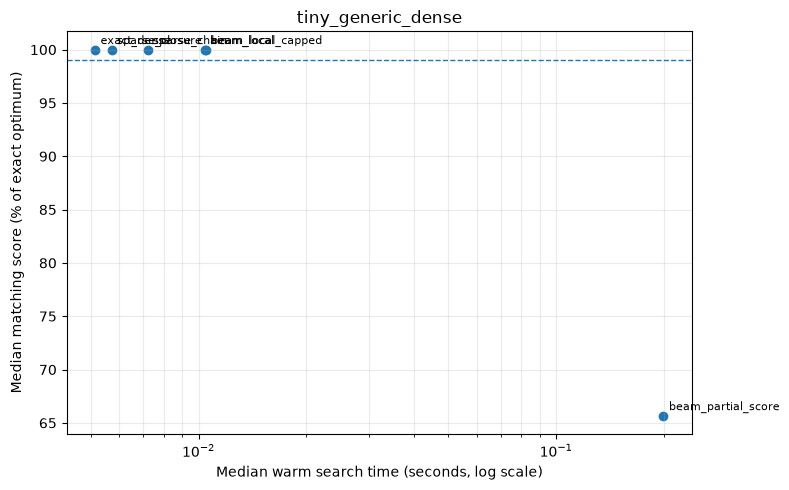

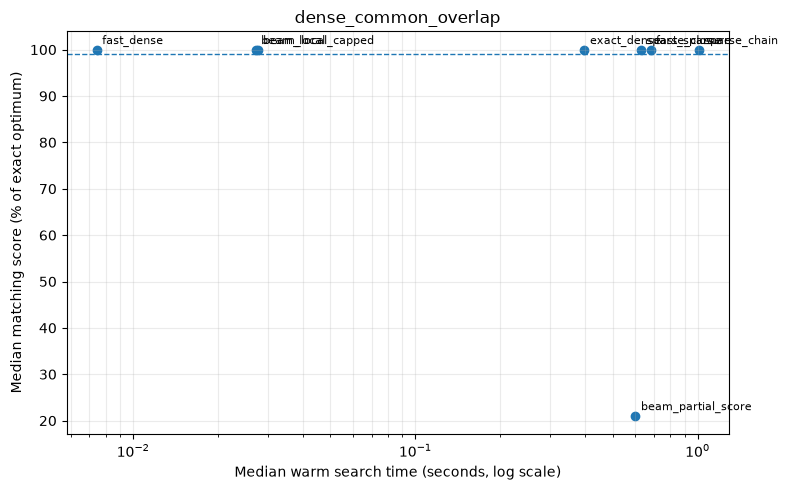

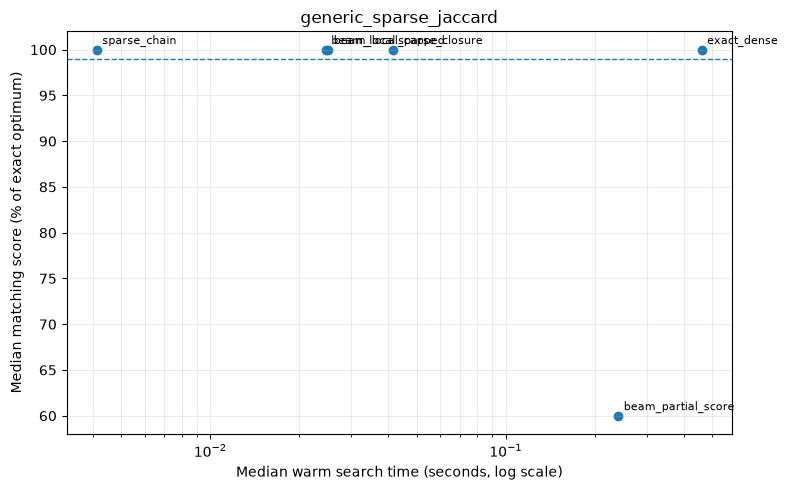

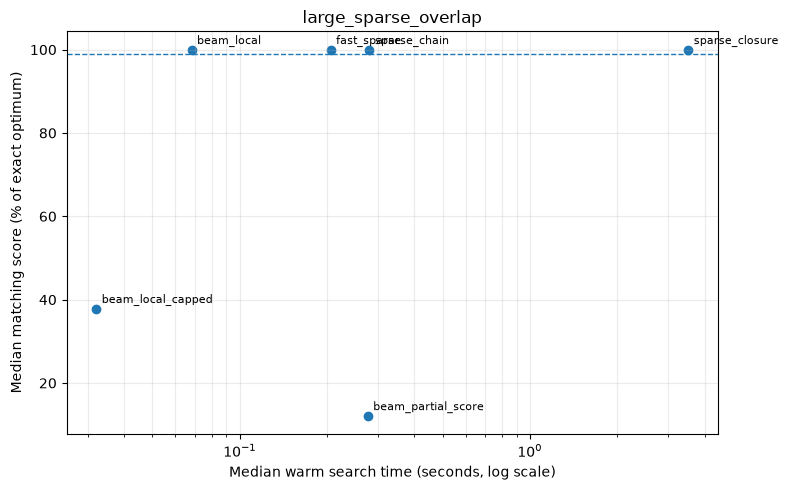

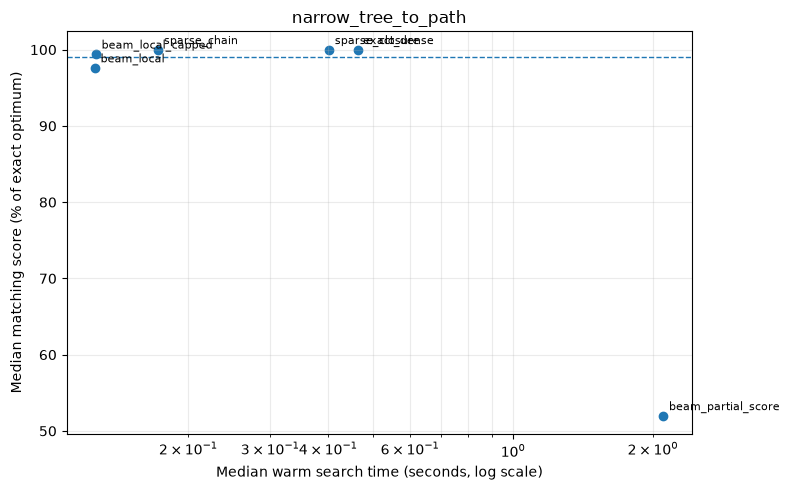

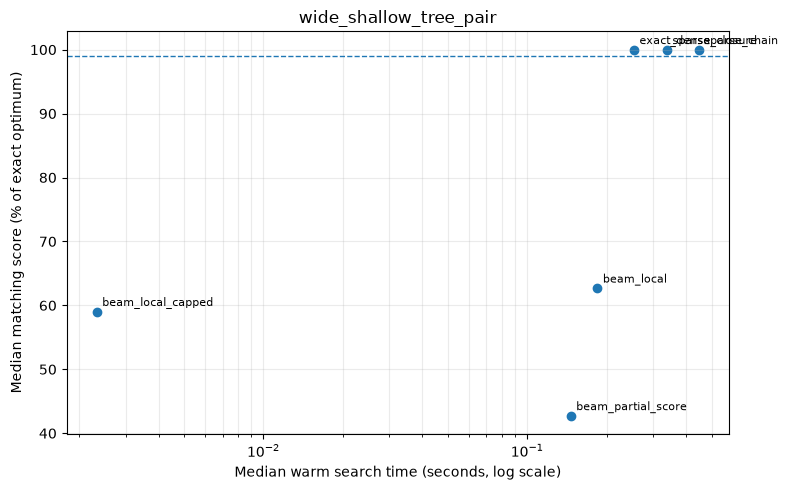

deep_rare_anchor_stress: no exact-oracle accuracy plot (scalability-only or no completed rows).


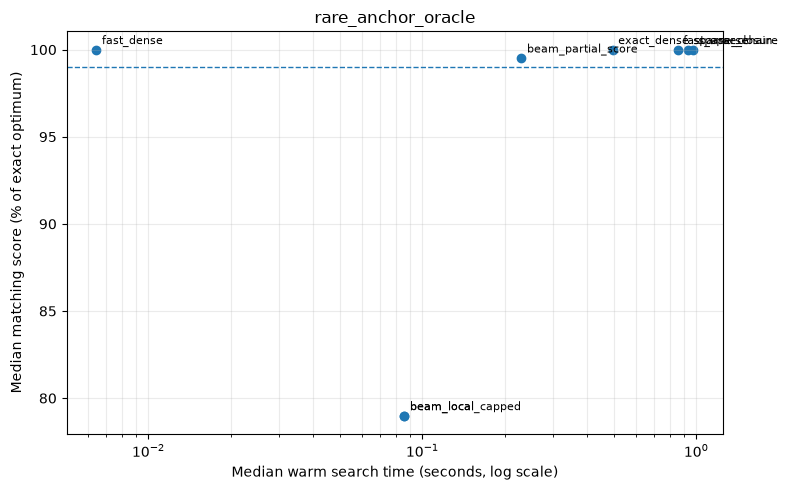

In [7]:
for regime_name in [item["name"] for item in config["regimes"]]:
    plot_data = compact[
        (compact["regime"] == regime_name)
        & compact["median_predict_seconds"].notna()
        & compact["median_accuracy_percent"].notna()
        & (compact["median_predict_seconds"] > 0.0)
    ].copy()
    if plot_data.empty:
        print(f"{regime_name}: no exact-oracle accuracy plot (scalability-only or no completed rows).")
        continue

    fig = plt.figure(figsize=(8, 5))
    ax = fig.add_subplot(111)
    ax.scatter(
        plot_data["median_predict_seconds"],
        plot_data["median_accuracy_percent"],
    )
    for _, point in plot_data.iterrows():
        ax.annotate(
            point["algorithm"],
            (point["median_predict_seconds"], point["median_accuracy_percent"]),
            xytext=(4, 4),
            textcoords="offset points",
            fontsize=8,
        )
    ax.axhline(100.0 * float(config["quality_floor"]), linestyle="--", linewidth=1)
    ax.set_xscale("log")
    ax.set_xlabel("Median warm search time (seconds, log scale)")
    ax.set_ylabel("Median matching score (% of exact optimum)")
    ax.set_title(regime_name)
    ax.grid(True, which="both", alpha=0.25)
    fig.tight_layout()
    plt.show()

## Algorithmic work and resource counters

These counters help distinguish a genuinely cheaper search from a fast result
caused only by implementation details.  Standard isolated runs also report
fresh-process wall time and lifetime peak resident memory.  Blank entries mean
that the quantity is not meaningful or not instrumented for that algorithm.


In [8]:
work_columns = [
    "dense_cells",
    "posting_hits",
    "diag_node_pair_score_evaluations",
    "diag_candidate_pairs_generated",
    "diag_positive_candidate_pairs",
    "diag_dp_cells_computed",
    "diag_states_generated",
    "diag_states_after_endpoint_pruning",
    "diag_states_retained",
    "diag_peak_frontier_size",
    "cold_fit_seconds",
    "cold_predict_seconds",
    "cold_setup_plus_predict_seconds",
    "fresh_process_total_seconds",
    "peak_rss_mib",
]
available_work_columns = [column for column in work_columns if column in rows.columns]

work_summary = (
    rows[rows["status"] == "ok"]
    .groupby(["regime", "algorithm"], observed=True)[available_work_columns]
    .median(numeric_only=True)
    .reset_index()
)
nonempty_work_columns = [
    column
    for column in available_work_columns
    if column in work_summary.columns and work_summary[column].notna().any()
]
work_summary = work_summary[["regime", "algorithm", *nonempty_work_columns]]
display(work_summary)


,regime,algorithm,dense_cells,posting_hits,diag_node_pair_score_evaluations,diag_candidate_pairs_generated,diag_positive_candidate_pairs,diag_dp_cells_computed,diag_states_generated,diag_states_after_endpoint_pruning,diag_states_retained,diag_peak_frontier_size,cold_fit_seconds,cold_predict_seconds,cold_setup_plus_predict_seconds,fresh_process_total_seconds,peak_rss_mib
0,deep_rare_anchor_stress,beam_local,144000000.0,33644758.0,21012.5,21012.5,4269.0,NaN,65040.0,28056.0,23405.0,200.0,0.000002,0.050209,0.050212,0.526100,193.976562
1,deep_rare_anchor_stress,beam_local_capped,144000000.0,33644758.0,20419.0,20419.0,4165.5,NaN,64071.0,27268.0,23401.0,200.0,0.000002,0.051350,0.051353,0.541326,193.976562
2,deep_rare_anchor_stress,beam_partial_score,144000000.0,33644758.0,179073.0,40585.5,40585.5,NaN,40585.5,28491.0,3461.5,200.0,0.000002,0.352180,0.352182,2.343600,193.976562
3,dense_common_overlap,beam_local,360000.0,605337.0,8839.0,8839.0,8163.0,NaN,24387.0,16319.0,6952.0,200.0,0.000002,0.027809,0.027811,0.408589,189.757812
4,dense_common_overlap,beam_local_capped,360000.0,605337.0,8839.0,8839.0,8163.0,NaN,24387.0,16319.0,6952.0,200.0,0.000002,0.028373,0.028375,0.406783,189.945312
5,dense_common_overlap,beam_partial_score,360000.0,605337.0,3378.0,130.0,130.0,NaN,130.0,127.0,127.0,64.0,0.000002,0.611160,0.611162,3.895523,189.757812
6,dense_common_overlap,exact_dense,360000.0,605337.0,360000.0,NaN,334137.0,360000.0,NaN,NaN,NaN,NaN,0.000002,0.405580,0.405582,2.644054,189.945312
7,dense_common_overlap,fast_dense,360000.0,605337.0,360000.0,NaN,NaN,360000.0,NaN,NaN,NaN,NaN,0.003203,0.105290,0.108489,0.421162,192.550781
8,dense_common_overlap,fast_sparse,360000.0,605337.0,334137.0,334137.0,334137.0,NaN,NaN,NaN,NaN,NaN,0.004525,0.699070,0.703595,4.371562,214.019531
9,dense_common_overlap,sparse_chain,360000.0,605337.0,334137.0,334137.0,334137.0,NaN,NaN,NaN,NaN,NaN,0.001621,1.035921,1.037542,6.364588,215.000000


## Save notebook-facing tables

The backend has already saved the complete row-level and summary data.  This
cell adds the compact tables used above and a copy of the exact notebook
configuration.

In [9]:
output_dir.mkdir(parents=True, exist_ok=True)
compact.to_csv(output_dir / "notebook_algorithm_table.csv", index=False)
regime_summary.to_csv(output_dir / "notebook_regime_summary.csv", index=False)
oracle_coverage.to_csv(output_dir / "notebook_oracle_coverage.csv", index=False)
work_summary.to_csv(output_dir / "notebook_work_summary.csv", index=False)
(output_dir / "notebook_config.json").write_text(
    json.dumps(config, indent=2, sort_keys=True, default=str),
    encoding="utf-8",
)

print("Saved:")
for name in (
    "benchmark_rows.csv",
    "benchmark_summary.csv",
    "benchmark_metadata.json",
    "notebook_algorithm_table.csv",
    "notebook_regime_summary.csv",
    "notebook_oracle_coverage.csv",
    "notebook_work_summary.csv",
    "notebook_config.json",
):
    print(f"  {output_dir / name}")

Saved:
  /home/asmi28/python_code/tree_matching/benchmarking/results/algorithm_ranking_standard_standard_v1/benchmark_rows.csv
  /home/asmi28/python_code/tree_matching/benchmarking/results/algorithm_ranking_standard_standard_v1/benchmark_summary.csv
  /home/asmi28/python_code/tree_matching/benchmarking/results/algorithm_ranking_standard_standard_v1/benchmark_metadata.json
  /home/asmi28/python_code/tree_matching/benchmarking/results/algorithm_ranking_standard_standard_v1/notebook_algorithm_table.csv
  /home/asmi28/python_code/tree_matching/benchmarking/results/algorithm_ranking_standard_standard_v1/notebook_regime_summary.csv
  /home/asmi28/python_code/tree_matching/benchmarking/results/algorithm_ranking_standard_standard_v1/notebook_oracle_coverage.csv
  /home/asmi28/python_code/tree_matching/benchmarking/results/algorithm_ranking_standard_standard_v1/notebook_work_summary.csv
  /home/asmi28/python_code/tree_matching/benchmarking/results/algorithm_ranking_standard_standard_v1/notebook

## Reading the result

Start with the raw accuracy and timing columns rather than the combined score.
A useful candidate method should either move the speed–accuracy frontier or
improve robustness/coverage in a regime where another method fails.  The
standard preset now supplies process isolation, fixed thread settings, timeouts,
peak-memory measurements, and timing uncertainty summaries.  The separate
throughput notebook answers the many-query, reusable-template-bank question.
